In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  BLOCK 1 — IMPORTS & CONFIG
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, Bidirectional, LSTM, Dense, Dropout,
    BatchNormalization, Multiply, Permute, Flatten,
    RepeatVector, Activation, Lambda, Embedding, Reshape, Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── CONFIG — all tunable hyperparameters in one place ─────────────────────────
CONFIG = {
    # Data
    "mat_path"       : "/content/water_dataset.mat",   # ← your Colab path
    "n_sites"        : 37,
    "n_features"     : 11,

    # Sequence
    "window_size"    : 8,     # WHY 8: autocorrelation drops sharply after lag 8
    "horizon"        : 1,     # one-step-ahead prediction

    # Architecture
    "cnn_filters"    : [64, 128],
    "kernel_size"    : 3,
    "lstm_units"     : 64,    # kept moderate — 423 train samples per site, avoid overfit
    "site_emb_dim"   : 8,     # site embedding dimension for cross-site generalization
    "dropout_rate"   : 0.3,
    "l2_reg"         : 1e-4,

    # Training
    "batch_size"     : 128,   # large batch OK — joint training across 37 sites
    "epochs"         : 200,
    "lr"             : 1e-3,
    "patience"       : 20,
    "model_path"     : "best_water_model.keras",
}

# Short feature names for display
FEATURE_NAMES = [
    'SpCond_max', 'pH_max', 'pH_min', 'SpCond_min', 'SpCond_mean',
    'DO_max', 'DO_mean', 'DO_min', 'Temp_mean', 'Temp_min', 'Temp_max'
]


In [ ]:
def load_dataset(mat_path: str):
    """
    Load the .mat file and reshape into clean numpy arrays.

    Returns
    -------
    X_tr : (423, 37, 11)  — train features  [timestep, site, feature]
    X_te : (282, 37, 11)  — test features
    Y_tr : (423, 37)      — train targets   [timestep, site]
    Y_te : (282, 37)      — test targets
    loc_groups : list of 3 arrays of 0-indexed site indices
    """
    mat = scipy.io.loadmat(mat_path)

    n_tr = mat['X_tr'].shape[1]   # 423
    n_te = mat['X_te'].shape[1]   # 282

    # Stack object arrays: each element is (37, 11)
    X_tr = np.stack([mat['X_tr'][0, t] for t in range(n_tr)], axis=0)  # (423, 37, 11)
    X_te = np.stack([mat['X_te'][0, t] for t in range(n_te)], axis=0)  # (282, 37, 11)

    Y_tr = mat['Y_tr'].T   # (423, 37)
    Y_te = mat['Y_te'].T   # (282, 37)

    # Location groups (0-indexed)
    loc_groups = [
        mat['location_group'][0, i].flatten() - 1   # MATLAB 1-indexed → 0-indexed
        for i in range(3)
    ]

    print("=" * 60)
    print(f"  X_tr : {X_tr.shape}  X_te : {X_te.shape}")
    print(f"  Y_tr : {Y_tr.shape}  Y_te : {Y_te.shape}")
    print(f"  Y range: [{min(Y_tr.min(), Y_te.min()):.4f}, {max(Y_tr.max(), Y_te.max()):.4f}]")
    print(f"  Location groups: {[len(g) for g in loc_groups]} sites")
    print("=" * 60)

    return X_tr, X_te, Y_tr, Y_te, loc_groups


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  BLOCK 3 — FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────────────────────
def engineer_features(X_tr, X_te, Y_tr, Y_te):
    """
    Build enriched feature matrices by appending lag and rolling features
    to the raw 11 features for each site independently.

    WHY: The raw 11 features are sensor readings at time t only. Adding:
      - Lag 1/2 of Y: explicit short-term memory (autocorr at lag1=0.92!)
      - Rolling mean/std of Y (window 4): local trend + volatility signal
      - Diff of Y: rate of change — helps model detect direction of drift
    These engineered features make the temporal pattern explicit for CNN.

    Input  shapes: X (T, 37, 11), Y (T, 37)
    Output shapes: X_eng (T, 37, n_eng), Y unchanged
    """
    T_tr, n_sites, n_feat = X_tr.shape
    T_te = X_te.shape[0]
    T_full = T_tr + T_te

    X_full = np.concatenate([X_tr, X_te], axis=0)   # (705, 37, 11)
    Y_full = np.concatenate([Y_tr, Y_te], axis=0)    # (705, 37)

    # --- Build extra features per site ---
    extra_list = []  # will be (705, 37, k)

    for lag in [1, 2, 3]:
        y_lag = np.zeros_like(Y_full)
        y_lag[lag:] = Y_full[:-lag]
        y_lag[:lag] = Y_full[0]           # fill initial with first value
        extra_list.append(y_lag[:, :, np.newaxis])

    # Rolling mean and std of Y (window=4)
    for w in [4, 8]:
        roll_mean = np.zeros_like(Y_full)
        roll_std  = np.zeros_like(Y_full)
        for t in range(T_full):
            lo = max(0, t - w + 1)
            roll_mean[t] = Y_full[lo:t+1].mean(axis=0)
            roll_std[t]  = Y_full[lo:t+1].std(axis=0) if (t - lo) > 0 else 0.0
        extra_list.append(roll_mean[:, :, np.newaxis])
        extra_list.append(roll_std[:, :, np.newaxis])

    # First difference of Y
    y_diff = np.zeros_like(Y_full)
    y_diff[1:] = Y_full[1:] - Y_full[:-1]
    extra_list.append(y_diff[:, :, np.newaxis])

    # Stack extra features: (705, 37, k)
    extra = np.concatenate(extra_list, axis=2)

    # DO_max - DO_min interaction (feature indices 5 and 7)
    do_range = (X_full[:, :, 5] - X_full[:, :, 7])[:, :, np.newaxis]
    # pH_max - pH_min interaction (indices 1 and 2)
    ph_range = (X_full[:, :, 1] - X_full[:, :, 2])[:, :, np.newaxis]

    X_eng = np.concatenate([X_full, extra, do_range, ph_range], axis=2)

    n_eng = X_eng.shape[2]
    print(f"  Engineered features: {n_feat} raw → {n_eng} total")

    X_tr_eng = X_eng[:T_tr]   # (423, 37, n_eng)
    X_te_eng = X_eng[T_tr:]   # (282, 37, n_eng)

    return X_tr_eng, X_te_eng, n_eng


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  BLOCK 4 — SEQUENCE CREATION (JOINT MULTI-SITE)
# ─────────────────────────────────────────────────────────────────────────────
def create_joint_sequences(X_tr, X_te, Y_tr, Y_te, window: int, horizon: int = 1):
    """
    Create sliding-window sequences across ALL 37 sites jointly.

    WHY joint training:
      Per-site: 423 train samples each → ~415 sequences → very few for LSTM.
      Joint:    423 × 37 = 15,651 train sequences → much richer gradient signal.
      Site embedding disambiguates sites so the model learns shared patterns
      while retaining site-specific behaviour through the embedding.

    Returns
    -------
    Xtr_seq  : (N_tr, window, n_eng)  — feature windows
    ytr_seq  : (N_tr,)                — targets
    site_tr  : (N_tr,)                — site index (0–36)
    (same for test)
    """
    T_tr, n_sites, n_feat = X_tr.shape

    # We use only X_tr for window creation to avoid leakage
    # but we need the val split to come from the end of train
    val_split = int(T_tr * 0.85)   # 85% train, 15% val (within training period)

    X_tr_part  = X_tr[:val_split]
    Y_tr_part  = Y_tr[:val_split]
    X_val_part = X_tr[val_split:]
    Y_val_part = Y_tr[val_split:]

    def make_seqs(X, Y):
        T = X.shape[0]
        Xs, ys, ss = [], [], []
        for s in range(n_sites):
            for t in range(window, T - horizon + 1):
                Xs.append(X[t - window:t, s, :])        # (window, n_feat)
                ys.append(Y[t + horizon - 1, s])         # scalar
                ss.append(s)                              # site index
        return np.array(Xs, dtype=np.float32), \
               np.array(ys,  dtype=np.float32), \
               np.array(ss,  dtype=np.int32)

    Xtr, ytr, str_ = make_seqs(X_tr_part,  Y_tr_part)
    Xva, yva, sva  = make_seqs(X_val_part, Y_val_part)
    Xte, yte, ste  = make_seqs(X_te,       Y_te)

    print(f"  Train seqs : {Xtr.shape}  |  Val seqs : {Xva.shape}  |  Test seqs : {Xte.shape}")
    return Xtr, ytr, str_, Xva, yva, sva, Xte, yte, ste



In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  BLOCK 5 — TEMPORAL ATTENTION
# ─────────────────────────────────────────────────────────────────────────────
def temporal_attention(inputs):
    """
    Soft attention over the time axis of BiLSTM outputs.

    WHY: Not every timestep contributes equally to predicting the next value.
    For water quality, a spike 2 steps ago matters more than a stable reading
    8 steps ago. Attention lets the model learn a dynamic weighted combination
    instead of relying on the final hidden state only.

    Returns: context vector (B, F), attention weights (B, T) for interpretability.
    """
    # Score each timestep: (B, T, F) → (B, T, 1) → (B, T)
    score  = Dense(1, activation="tanh", use_bias=True)(inputs)
    score  = Flatten()(score)
    weight = Activation("softmax", name="attention_weights")(score)

    # Weighted sum: broadcast weights across feature dimension
    weight_3d = RepeatVector(inputs.shape[-1])(weight)   # (B, F, T)
    weight_3d = Permute([2, 1])(weight_3d)               # (B, T, F)
    attended  = Multiply()([inputs, weight_3d])           # (B, T, F)
    context   = Lambda(lambda x: tf.reduce_sum(x, axis=1),
                       name="context")(attended)          # (B, F)
    return context, weight


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  BLOCK 6 — MODEL ARCHITECTURE
# ─────────────────────────────────────────────────────────────────────────────
def build_model(window: int, n_feat: int, n_sites: int, cfg: dict) -> Model:
    """
    CNN-BiLSTM-Attention with Site Embedding.

    Architecture:
    ┌──────────────────────────────────────────────────────────┐
    │  Input (window, n_feat)   + Site ID (scalar)            │
    │  ↓                          ↓                           │
    │  Conv1D(64, k=3, causal)    Embedding(37, 8) → Flatten  │
    │  BatchNorm → Dropout(0.15)  ↓                           │
    │  Conv1D(128, k=3, causal)   ┐                           │
    │  BatchNorm → Dropout(0.15)  │ Concatenated at dense head│
    │  ↓                          │                           │
    │  BiLSTM(64, return_seq=T)   │                           │
    │  BatchNorm → Dropout(0.3)   │                           │
    │  BiLSTM(32, return_seq=T)   │                           │
    │  BatchNorm → Dropout(0.3)   │                           │
    │  Attention → context(64)    │                           │
    │  Concat(context, site_emb) ←┘                           │
    │  Dense(64, relu) → Dense(32, relu) → Dense(1)           │
    └──────────────────────────────────────────────────────────┘

    WHY each design choice:
    - Causal padding in Conv1D: no future leakage at conv stage.
    - Stacked BiLSTM (return_sequences=True on both):
        • Layer 1 (64 units/dir): captures broad temporal context.
        • Layer 2 (32 units/dir): refines for attention input.
        WHY BiLSTM not LSTM: at window=8 the "future" within the window
        is observable context, not a leak. BiLSTM reads both directions
        to detect trends approaching an event as well as past context.
    - Site Embedding (dim=8): 37 sites mapped to 8-dim learned vectors.
        WHY: Sites share physics (same river basin) but differ in local
        conditions. Embedding captures site-specific bias in 8 dims
        without adding 37 separate dense paths.
    - Huber loss (delta=0.1): robust to the occasional normalized spike
        in Y (e.g., sites 11, 27, 28 reach Y≈1.0 occasionally).
    - Gradient clipping (clipnorm=1.0): prevents BiLSTM gradient explosion.
    """
    dr   = cfg["dropout_rate"]
    l2r  = cfg["l2_reg"]
    lstu = cfg["lstm_units"]
    cf   = cfg["cnn_filters"]
    ks   = cfg["kernel_size"]

    # ── Input branches ────────────────────────────────────────────────────────
    seq_input  = Input(shape=(window, n_feat), name="sequence_input")
    site_input = Input(shape=(1,),             name="site_input")

    # ── Site Embedding ────────────────────────────────────────────────────────
    site_emb = Embedding(input_dim=n_sites,
                         output_dim=cfg["site_emb_dim"],
                         name="site_embedding")(site_input)
    site_emb = Flatten(name="site_flatten")(site_emb)   # (B, site_emb_dim)

    # ── CNN Block 1 (local short-range patterns) ──────────────────────────────
    x = Conv1D(filters=cf[0], kernel_size=ks,
               padding="causal", activation="relu",
               kernel_regularizer=l2(l2r),
               name="conv1")(seq_input)
    x = BatchNormalization(name="bn1")(x)
    x = Dropout(dr * 0.5, name="drop_conv1")(x)

    # ── CNN Block 2 (mid-range trends) ────────────────────────────────────────
    x = Conv1D(filters=cf[1], kernel_size=ks,
               padding="causal", activation="relu",
               kernel_regularizer=l2(l2r),
               name="conv2")(x)
    x = BatchNormalization(name="bn2")(x)
    x = Dropout(dr * 0.5, name="drop_conv2")(x)

    # ── BiLSTM Layer 1 (broad temporal context) ───────────────────────────────
    x = Bidirectional(
            LSTM(lstu, return_sequences=True,
                 kernel_regularizer=l2(l2r),
                 recurrent_regularizer=l2(l2r * 0.5)),
            name="bilstm1")(x)
    x = BatchNormalization(name="bn3")(x)
    x = Dropout(dr, name="drop_lstm1")(x)

    # ── BiLSTM Layer 2 (fine-grained, feeds attention) ───────────────────────
    x = Bidirectional(
            LSTM(lstu // 2, return_sequences=True,
                 kernel_regularizer=l2(l2r),
                 recurrent_regularizer=l2(l2r * 0.5)),
            name="bilstm2")(x)
    x = BatchNormalization(name="bn4")(x)
    x = Dropout(dr, name="drop_lstm2")(x)

    # ── Temporal Attention ────────────────────────────────────────────────────
    context, _ = temporal_attention(x)    # (B, lstu)

    # ── Fuse temporal context + site identity ─────────────────────────────────
    fused = Concatenate(name="fuse")([context, site_emb])

    # ── Regression Head ───────────────────────────────────────────────────────
    h = Dense(64, activation="relu", kernel_regularizer=l2(l2r), name="dense1")(fused)
    h = Dropout(dr * 0.5, name="drop_dense1")(h)
    h = Dense(32, activation="relu", kernel_regularizer=l2(l2r), name="dense2")(h)
    out = Dense(1, name="output")(h)

    model = Model(inputs=[seq_input, site_input], outputs=out,
                  name="CNN_BiLSTM_Attention")

    optimizer = Adam(learning_rate=cfg["lr"], clipnorm=1.0)
    model.compile(optimizer=optimizer,
                  loss=tf.keras.losses.Huber(delta=0.1),
                  metrics=["mae"])
    return model



In [ ]:
def build_lstm_cnn_model(window: int, n_feat: int, n_sites: int, cfg: dict) -> Model:
    """
    LSTM-CNN: LSTM first extracts temporal dependencies,
    then CNN extracts local patterns from LSTM hidden states.
    Opposite order to the main CNN-BiLSTM model.
    """
    dr  = cfg["dropout_rate"]
    l2r = cfg["l2_reg"]

    seq_input  = Input(shape=(window, n_feat), name="sequence_input")
    site_input = Input(shape=(1,),             name="site_input")

    site_emb = Embedding(input_dim=n_sites,
                         output_dim=cfg["site_emb_dim"],
                         name="site_embedding")(site_input)
    site_emb = Flatten(name="site_flatten")(site_emb)

    # LSTM first — learns temporal dependencies
    x = LSTM(128, return_sequences=True,
             kernel_regularizer=l2(l2r),
             recurrent_regularizer=l2(l2r * 0.5),
             name="lstm1")(seq_input)
    x = BatchNormalization(name="bn1")(x)
    x = Dropout(dr, name="drop_lstm1")(x)

    x = LSTM(64, return_sequences=True,
             kernel_regularizer=l2(l2r),
             recurrent_regularizer=l2(l2r * 0.5),
             name="lstm2")(x)
    x = BatchNormalization(name="bn2")(x)
    x = Dropout(dr, name="drop_lstm2")(x)

    # CNN on top of LSTM outputs — extracts local patterns from hidden states
    x = Conv1D(filters=64, kernel_size=3, padding="causal",
               activation="relu", kernel_regularizer=l2(l2r),
               name="conv1")(x)
    x = BatchNormalization(name="bn3")(x)
    x = Dropout(dr * 0.5, name="drop_conv1")(x)

    x = Conv1D(filters=128, kernel_size=3, padding="causal",
               activation="relu", kernel_regularizer=l2(l2r),
               name="conv2")(x)
    x = BatchNormalization(name="bn4")(x)
    x = Dropout(dr * 0.5, name="drop_conv2")(x)

    # Temporal attention (reuse same function)
    context, _ = temporal_attention(x)

    fused = Concatenate(name="fuse")([context, site_emb])

    h = Dense(64, activation="relu", kernel_regularizer=l2(l2r), name="dense1")(fused)
    h = Dropout(dr * 0.5, name="drop_dense1")(h)
    h = Dense(32, activation="relu", kernel_regularizer=l2(l2r), name="dense2")(h)
    out = Dense(1, name="output")(h)

    model = Model(inputs=[seq_input, site_input], outputs=out,
                  name="LSTM_CNN_Attention")

    optimizer = Adam(learning_rate=cfg["lr"], clipnorm=1.0)
    model.compile(optimizer=optimizer,
                  loss=tf.keras.losses.Huber(delta=0.1),
                  metrics=["mae"])
    return model

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  BLOCK 7 — TRAINING
# ─────────────────────────────────────────────────────────────────────────────
def train_model(model, Xtr, ytr, str_, Xva, yva, sva, cfg: dict):
    """
    Full callback stack:
    - EarlyStopping (patience=20, restore_best): stops before overfit.
    - ReduceLROnPlateau: halves LR when val_loss stalls for 10 epochs.
      WHY factor=0.5: aggressive enough to escape oscillation.
    - ModelCheckpoint: persists best weights on disk.

    shuffle=True: OK for joint training because we've already shuffled sites;
    temporal order within each site is preserved by the window construction.
    """
    callbacks = [
        EarlyStopping(monitor="val_loss",
                      patience=cfg["patience"],
                      restore_best_weights=True,
                      verbose=1),
        ReduceLROnPlateau(monitor="val_loss",
                          factor=0.5,
                          patience=cfg["patience"] // 2,
                          min_lr=1e-6,
                          verbose=1),
        ModelCheckpoint(cfg["model_path"],
                        monitor="val_loss",
                        save_best_only=True,
                        verbose=0),
    ]

    history = model.fit(
        [Xtr, str_], ytr,
        validation_data=([Xva, sva], yva),
        epochs=cfg["epochs"],
        batch_size=cfg["batch_size"],
        callbacks=callbacks,
        verbose=1,
        shuffle=True,     # WHY True: sequences are already self-contained windows
    )
    return history


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  BLOCK 8 — EVALUATION
# ─────────────────────────────────────────────────────────────────────────────
def evaluate_model(model, Xte, yte, ste, split_name="Test"):
    """
    Compute RMSE, MAE, R², MAPE in the normalized (original .mat) scale.
    Y is already normalized in the .mat file — no inverse transform needed.
    """
    y_pred = model.predict([Xte, ste], verbose=0).flatten()
    y_true = yte.flatten()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    eps  = 1e-8
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100

    print(f"\n{'─'*50}")
    print(f"  {split_name} Evaluation  ({len(y_true):,} samples)")
    print(f"{'─'*50}")
    print(f"  RMSE : {rmse:.6f}")
    print(f"  MAE  : {mae:.6f}")
    print(f"  R²   : {r2:.4f}")
    print(f"  MAPE : {mape:.2f}%")
    print(f"{'─'*50}")

    return {"rmse": rmse, "mae": mae, "r2": r2, "mape": mape,
            "y_true": y_true, "y_pred": y_pred}


def evaluate_per_site(model, Xte, yte, ste, n_sites=37):
    """
    Break down R² per site — essential for diagnosing generalization gaps
    across the 3 location groups.
    """
    y_pred = model.predict([Xte, ste], verbose=0).flatten()
    y_true = yte.flatten()

    print(f"\n{'─'*60}")
    print(f"  Per-Site R² Breakdown")
    print(f"{'─'*60}")
    site_r2 = {}
    for s in range(n_sites):
        mask = ste == s
        if mask.sum() < 2:
            continue
        r2 = r2_score(y_true[mask], y_pred[mask])
        site_r2[s] = r2
        print(f"  Site {s:2d}: R²={r2:.4f}  (n={mask.sum()})")

    overall = np.mean(list(site_r2.values()))
    print(f"\n  Mean R² across {len(site_r2)} sites: {overall:.4f}")
    return site_r2



In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  BLOCK 9 — VISUALIZATIONS
# ─────────────────────────────────────────────────────────────────────────────
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(history.history['loss'],     label='Train Loss', linewidth=1.5)
    axes[0].plot(history.history['val_loss'], label='Val Loss',   linewidth=1.5)
    axes[0].set_title('Huber Loss', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['mae'],     label='Train MAE', linewidth=1.5)
    axes[1].plot(history.history['val_mae'], label='Val MAE',   linewidth=1.5)
    axes[1].set_title('MAE', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.suptitle('Training History — CNN-BiLSTM-Attention', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_test_results(results: dict):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Time-series overlay (first 300 samples for clarity) ──────────────────
    n_show = min(300, len(results['y_true']))
    axes[0].plot(results['y_true'][:n_show], label='Actual',    alpha=0.85, lw=1.2)
    axes[0].plot(results['y_pred'][:n_show], label='Predicted', alpha=0.85, lw=1.2,
                 linestyle='--')
    axes[0].set_title(f"Prediction vs Actual  |  R²={results['r2']:.4f}",
                      fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Sample'); axes[0].set_ylabel('Normalized Target (Y)')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # ── Scatter plot ──────────────────────────────────────────────────────────
    axes[1].scatter(results['y_true'], results['y_pred'],
                    alpha=0.25, s=6, color='steelblue', rasterized=True)
    lo = min(results['y_true'].min(), results['y_pred'].min())
    hi = max(results['y_true'].max(), results['y_pred'].max())
    axes[1].plot([lo, hi], [lo, hi], 'r--', lw=2, label='Perfect fit')
    axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted')
    axes[1].set_title(f"Scatter  |  RMSE={results['rmse']:.6f}  MAE={results['mae']:.6f}",
                      fontsize=12, fontweight='bold')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('test_results.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_training_history_comparison(history_cba, history_lca):
    """IEEE Fig: side-by-side training curves for both models."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('Training Curves — Model Comparison', fontsize=13, fontweight='bold')

    for ax, key, ylabel in zip(axes, ['loss', 'mae'], ['Huber Loss', 'MAE']):
        ax.plot(history_cba.history[key],     color='#2196F3', lw=1.5, label='CNN-BiLSTM-Attn Train')
        ax.plot(history_cba.history[f'val_{key}'], color='#2196F3', lw=1.5, ls='--', label='CNN-BiLSTM-Attn Val')
        ax.plot(history_lca.history[key],     color='#F44336', lw=1.5, label='LSTM-CNN-Attn Train')
        ax.plot(history_lca.history[f'val_{key}'], color='#F44336', lw=1.5, ls='--', label='LSTM-CNN-Attn Val')
        ax.set_xlabel('Epoch', fontsize=11); ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(ylabel, fontsize=11, fontweight='bold')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('ieee_fig1_training_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_model_comparison(res_cba, res_lca):
    """IEEE Fig: grouped bar chart of all 4 metrics."""
    metrics = ['RMSE', 'MAE', 'R²', 'MAPE (%)']
    cba_vals = [res_cba['rmse'], res_cba['mae'], res_cba['r2'], res_cba['mape']]
    lca_vals = [res_lca['rmse'], res_lca['mae'], res_lca['r2'], res_lca['mape']]

    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    bars1 = ax.bar(x - width/2, cba_vals, width, label='CNN-BiLSTM-Attn',
                   color='#2196F3', edgecolor='white')
    bars2 = ax.bar(x + width/2, lca_vals, width, label='LSTM-CNN-Attn',
                   color='#F44336', edgecolor='white')

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=11)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title('Performance Comparison — All Metrics', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10); ax.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('ieee_fig2_metric_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_scatter_comparison(res_cba, res_lca):
    """IEEE Fig: actual vs predicted scatter for both models side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Actual vs Predicted — Scatter Plots', fontsize=13, fontweight='bold')

    for ax, res, label, color in zip(
        axes,
        [res_cba, res_lca],
        ['CNN-BiLSTM-Attention', 'LSTM-CNN-Attention'],
        ['#2196F3', '#F44336']
    ):
        ax.scatter(res['y_true'], res['y_pred'], alpha=0.2, s=5,
                   color=color, rasterized=True)
        lo = min(res['y_true'].min(), res['y_pred'].min())
        hi = max(res['y_true'].max(), res['y_pred'].max())
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1.5, label='Perfect fit')
        ax.set_xlabel('Actual (Normalized)', fontsize=11)
        ax.set_ylabel('Predicted (Normalized)', fontsize=11)
        ax.set_title(f'{label}\nR²={res["r2"]:.4f}  RMSE={res["rmse"]:.6f}',
                     fontsize=10, fontweight='bold')
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('ieee_fig3_scatter_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_residuals_comparison(res_cba, res_lca):
    """IEEE Fig: residual distributions for both models."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('Residual Distribution — Error Analysis', fontsize=13, fontweight='bold')

    for ax, res, label, color in zip(
        axes,
        [res_cba, res_lca],
        ['CNN-BiLSTM-Attention', 'LSTM-CNN-Attention'],
        ['#2196F3', '#F44336']
    ):
        residuals = res['y_true'] - res['y_pred']
        ax.hist(residuals, bins=60, color=color, edgecolor='white', alpha=0.85)
        ax.axvline(0,              color='black', lw=1.5, ls='--', label='Zero error')
        ax.axvline(residuals.mean(), color='orange', lw=1.5, ls='--',
                   label=f'Mean={residuals.mean():.5f}')
        ax.set_xlabel('Residual', fontsize=11)
        ax.set_ylabel('Count', fontsize=11)
        ax.set_title(f'{label}\nStd={residuals.std():.5f}', fontsize=10, fontweight='bold')
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('ieee_fig4_residuals_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()


def plot_per_site_r2_comparison(site_r2_cba, site_r2_lca, loc_groups):
    """IEEE Fig: per-site R² for both models side by side."""
    sites = sorted(set(site_r2_cba.keys()) & set(site_r2_lca.keys()))
    cba_vals = [site_r2_cba[s] for s in sites]
    lca_vals = [site_r2_lca[s] for s in sites]

    x = np.arange(len(sites))
    width = 0.4

    fig, ax = plt.subplots(figsize=(18, 5))
    ax.bar(x - width/2, cba_vals, width, label='CNN-BiLSTM-Attn',
           color='#2196F3', edgecolor='white', alpha=0.9)
    ax.bar(x + width/2, lca_vals, width, label='LSTM-CNN-Attn',
           color='#F44336', edgecolor='white', alpha=0.9)

    ax.axhline(0.85, color='black',  ls='--', lw=1.5, label='R²=0.85 target')
    ax.axhline(np.mean(cba_vals), color='#2196F3', ls=':', lw=1.5,
               label=f'CNN-BiLSTM mean={np.mean(cba_vals):.3f}')
    ax.axhline(np.mean(lca_vals), color='#F44336', ls=':', lw=1.5,
               label=f'LSTM-CNN mean={np.mean(lca_vals):.3f}')

    ax.set_xticks(x); ax.set_xticklabels(sites, fontsize=7)
    ax.set_xlabel('Site Index', fontsize=11)
    ax.set_ylabel('R²', fontsize=11)
    ax.set_title('Per-Site R² Comparison — All 37 Sites', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('ieee_fig5_persite_r2_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  BLOCK 10 — OPTIONAL: WINDOW SIZE TUNER
# ─────────────────────────────────────────────────────────────────────────────
def tune_window_size(X_tr, X_te, Y_tr, Y_te, n_eng: int,
                     candidates: list, cfg: dict) -> int:
    """
    Lightweight 30-epoch trials to find the optimal window size.
    WHY: Autocorrelation analysis suggests window=8 is optimal, but
    this function lets you verify on your specific data in ~5 minutes.
    """
    results = {}
    for w in candidates:
        print(f"\n── Trying window = {w} ──")
        Xtr, ytr, str_, Xva, yva, sva, Xte_s, yte_s, ste_s = create_joint_sequences(
            X_tr, X_te, Y_tr, Y_te, window=w, horizon=cfg["horizon"]
        )
        m = build_model(w, n_eng, cfg["n_sites"], cfg)
        cb = [EarlyStopping(monitor="val_loss", patience=8,
                            restore_best_weights=True, verbose=0),
              ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=4, min_lr=1e-6, verbose=0)]
        m.fit([Xtr, str_], ytr, validation_data=([Xva, sva], yva),
              epochs=30, batch_size=cfg["batch_size"],
              callbacks=cb, verbose=0, shuffle=True)
        res = evaluate_model(m, Xte_s, yte_s, ste_s, split_name=f"Window={w}")
        results[w] = res["r2"]

    best_w = max(results, key=results.get)
    print(f"\n✔ Best window: {best_w}  (R²={results[best_w]:.4f})")
    print(f"  All results: {results}")
    return best_w




  WATER QUALITY PREDICTION — MODEL COMPARISON

[1] Loading dataset...
  X_tr : (423, 37, 11)  X_te : (282, 37, 11)
  Y_tr : (423, 37)  Y_te : (282, 37)
  Y range: [0.5741, 1.0000]
  Location groups: [1, 8, 28] sites

[2] Engineering features...
  Engineered features: 11 raw → 21 total

[3] Using window_size = 8

[4] Creating sequences...
  Train seqs : (12987, 8, 21)  |  Val seqs : (2072, 8, 21)  |  Test seqs : (10138, 8, 21)

[5a] Building CNN-BiLSTM-Attention (original)...


Model: "CNN_BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 8, 21)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv1D)      │ (None, 8, 64)     │      4,096 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 8, 64)     │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_conv1          │ (None, 8, 64)     │          0 │ bn1[0][0]         │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv1D)      │ (None, 8, 128)    │     24,704 │ drop_conv1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 8, 128)    │        512 │ conv2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_conv2          │ (None, 8, 128)    │          0 │ bn2[0][0]         │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm1             │ (None, 8, 128)    │     98,816 │ drop_conv2[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn3                 │ (None, 8, 128)    │        512 │ bilstm1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_lstm1          │ (None, 8, 128)    │          0 │ bn3[0][0]         │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm2             │ (None, 8, 64)     │     41,216 │ drop_lstm1[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn4                 │ (None, 8, 64)     │        256 │ bilstm2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_lstm2          │ (None, 8, 64)     │          0 │ bn4[0][0]         │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8, 1)      │         65 │ drop_lstm2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8)         │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ (None, 8)         │          0 │ flatten[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 64, 8)     │          0 │ attention_weight… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 8, 64)     │          0 │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 177,514 (693.41 KB)

 Trainable params: 176,746 (690.41 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 8, 21)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm1 (LSTM)        │ (None, 8, 128)    │     76,800 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 8, 128)    │        512 │ lstm1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_lstm1          │ (None, 8, 128)    │          0 │ bn1[0][0]         │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm2 (LSTM)        │ (None, 8, 64)     │     49,408 │ drop_lstm1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 8, 64)     │        256 │ lstm2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_lstm2          │ (None, 8, 64)     │          0 │ bn2[0][0]         │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv1D)      │ (None, 8, 64)     │     12,352 │ drop_lstm2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn3                 │ (None, 8, 64)     │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_conv1          │ (None, 8, 64)     │          0 │ bn3[0][0]         │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv1D)      │ (None, 8, 128)    │     24,704 │ drop_conv1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn4                 │ (None, 8, 128)    │        512 │ conv2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_conv2          │ (None, 8, 128)    │          0 │ bn4[0][0]         │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8, 1)      │        129 │ drop_conv2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 8)         │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ (None, 8)         │          0 │ flatten_1[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_1     │ (None, 128, 8)    │          0 │ attention_weight… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_1 (Permute) │ (None, 8, 128)    │          0 │ repeat_vector_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ site_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                 

 Total params: 176,106 (687.91 KB)

 Trainable params: 175,338 (684.91 KB)

 Non-trainable params: 768 (3.00 KB)


[6b] Training LSTM-CNN-Attention...
Epoch 1/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 17s 83ms/step - loss: 0.0550 - mae: 0.0900 - val_loss: 0.0588 - val_mae: 0.2364 - learning_rate: 0.0010
Epoch 2/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 8s 74ms/step - loss: 0.0343 - mae: 0.0391 - val_loss: 0.0294 - val_mae: 0.0678 - learning_rate: 0.0010
Epoch 3/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - loss: 0.0228 - mae: 0.0292 - val_loss: 0.0184 - val_mae: 0.0216 - learning_rate: 0.0010
Epoch 4/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - loss: 0.0153 - mae: 0.0229 - val_loss: 0.0124 - val_mae: 0.0203 - learning_rate: 0.0010
Epoch 5/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 11s 71ms/step - loss: 0.0103 - mae: 0.0205 - val_loss: 0.0088 - val_mae: 0.0322 - learning_rate: 0.0010
Epoch 6/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - loss: 0.0069 - mae: 0.0175 - val_loss: 0.0058 - val_mae: 0.0203 - learning_rate: 0.0010
Epoch 7/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - loss: 0.0047 - mae: 0.0157 - val_loss: 0

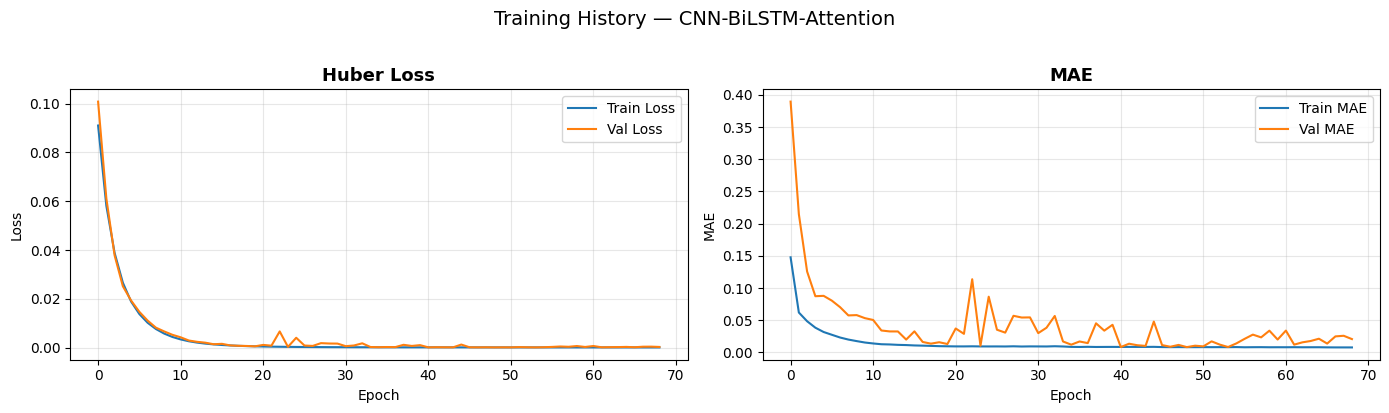

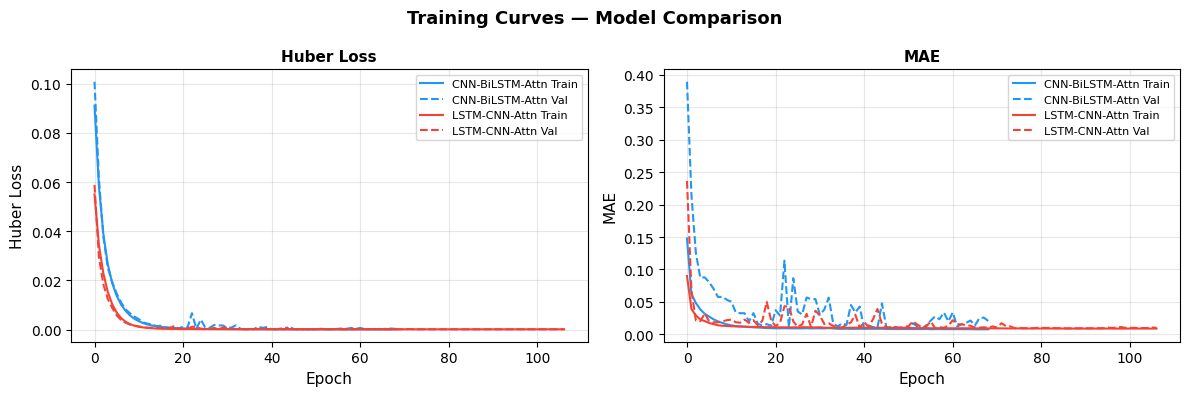

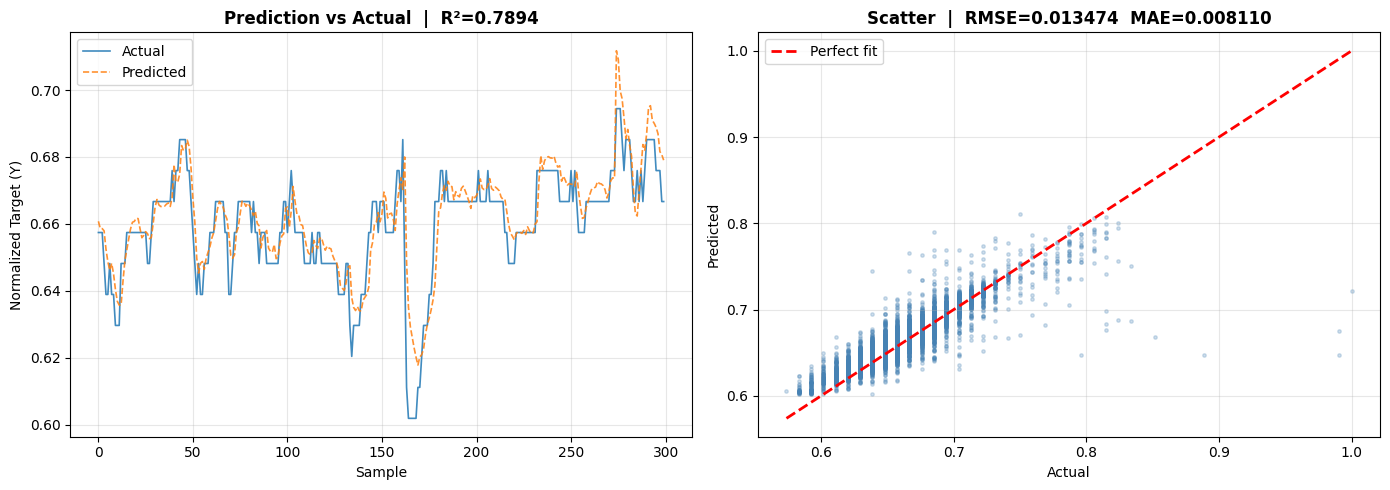

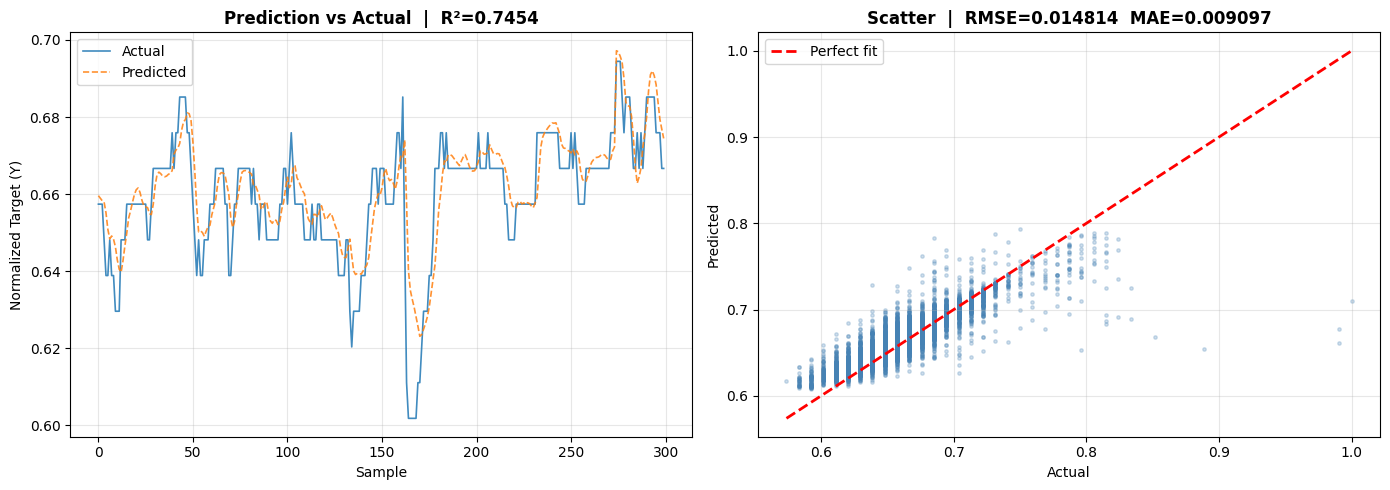

NameError: name 'plot_per_site_r2' is not defined

In [ ]:
if __name__ == "__main__":

    print("\n" + "=" * 60)
    print("  WATER QUALITY PREDICTION — MODEL COMPARISON")
    print("=" * 60)

    print("\n[1] Loading dataset...")
    X_tr, X_te, Y_tr, Y_te, loc_groups = load_dataset(CONFIG["mat_path"])

    print("\n[2] Engineering features...")
    X_tr_eng, X_te_eng, n_eng = engineer_features(X_tr, X_te, Y_tr, Y_te)
    CONFIG["n_features"] = n_eng

    print(f"\n[3] Using window_size = {CONFIG['window_size']}")

    print("\n[4] Creating sequences...")
    Xtr, ytr, str_, Xva, yva, sva, Xte, yte, ste = create_joint_sequences(
        X_tr_eng, X_te_eng, Y_tr, Y_te,
        window=CONFIG["window_size"], horizon=CONFIG["horizon"]
    )

    # ── Train CNN-BiLSTM-Attention (original) ────────────────────────────────
    print("\n[5a] Building CNN-BiLSTM-Attention (original)...")
    CONFIG["model_path"] = "cnn_bilstm_attn_best.keras"
    model_cba = build_model(CONFIG["window_size"], n_eng, CONFIG["n_sites"], CONFIG)
    model_cba.summary()
    print("\n[6a] Training CNN-BiLSTM-Attention...")
    history_cba = train_model(model_cba, Xtr, ytr, str_, Xva, yva, sva, CONFIG)

    # ── Train LSTM-CNN-Attention (new) ───────────────────────────────────────
    print("\n[5b] Building LSTM-CNN-Attention (new)...")
    CONFIG["model_path"] = "lstm_cnn_attn_best.keras"
    model_lca = build_lstm_cnn_model(CONFIG["window_size"], n_eng, CONFIG["n_sites"], CONFIG)
    model_lca.summary()
    print("\n[6b] Training LSTM-CNN-Attention...")
    history_lca = train_model(model_lca, Xtr, ytr, str_, Xva, yva, sva, CONFIG)

    # ── Evaluate both ─────────────────────────────────────────────────────────
    print("\n[7] Evaluating both models...")
    res_cba  = evaluate_model(model_cba, Xte, yte, ste, "CNN-BiLSTM-Attn  (Test)")
    res_lca  = evaluate_model(model_lca, Xte, yte, ste, "LSTM-CNN-Attn    (Test)")
    site_r2_cba = evaluate_per_site(model_cba, Xte, yte, ste, CONFIG["n_sites"])
    site_r2_lca = evaluate_per_site(model_lca, Xte, yte, ste, CONFIG["n_sites"])

    # ── IEEE Figures ──────────────────────────────────────────────────────────
    print("\n[8] Generating IEEE figures...")
    plot_training_history(history_cba)
    plot_training_history_comparison(history_cba, history_lca)
    plot_test_results(res_cba)
    plot_test_results(res_lca)
    plot_per_site_r2(site_r2_cba, loc_groups)
    plot_model_comparison(res_cba, res_lca)
    plot_scatter_comparison(res_cba, res_lca)
    plot_residuals_comparison(res_cba, res_lca)


    print("\n" + "=" * 60)
    print("  FINAL COMPARISON")
    print("=" * 60)
    print(f"  {'Metric':<10}  {'CNN-BiLSTM-Attn':>18}  {'LSTM-CNN-Attn':>15}")
    print(f"  {'-'*46}")
    print(f"  {'RMSE':<10}  {res_cba['rmse']:>18.6f}  {res_lca['rmse']:>15.6f}")
    print(f"  {'MAE':<10}  {res_cba['mae']:>18.6f}  {res_lca['mae']:>15.6f}")
    print(f"  {'R²':<10}  {res_cba['r2']:>18.4f}  {res_lca['r2']:>15.4f}")
    print(f"  {'MAPE %':<10}  {res_cba['mape']:>18.2f}  {res_lca['mape']:>15.2f}")
    print("=" * 60)